This notebook compares the dist change of different embedding methods, namely `Gaussian Embedding(GE)`, `scVI/VAE`, `Diffusion map(DF)`, `UMAP`, `t-SNE`. We compute the `Coefficient of Variation(CV)` of dist_embedding/dist_original for each edges in KNN constructed in the original space. **Small CV implicates low variation of the dist ratio, thus methods with small CV preserves the local metric better.**

## **Defaults**

In [23]:
import os
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import scvi
import scvelo as scv
from scipy.sparse import csr_matrix
from utils import kde_lowess

In [45]:
data_path='data/'
# ellipsoid, saddle, fourwell
data_name = 'saddle'

In [46]:
# Parameters: k_nei for KNN, L for latent dimension, seed for random seed
[k_nei, K, L, seed] = [10, 2, 3, 0]

random.seed(seed)
result_path = 'VAEcvresults/'+data_name+str([k_nei, L, seed])+'/'
figure_path = result_path
cmap = plt.colormaps['Spectral_r']

folder = os.path.exists(result_path)
if not folder:                   
    os.makedirs(result_path)  

## **Data generation**

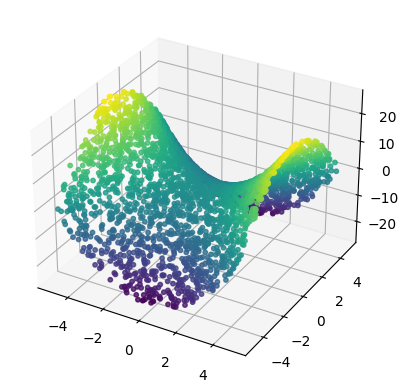

In [47]:
if data_name == 'ellipsoid':
    n_samples=3000

    g3 = np.random.randn(3,n_samples)
    gr = np.linalg.norm(g3,axis=0)

    x1,x2,x3 = 4*g3/gr
    x2 = 4*x2

    color_label=np.zeros((n_samples))
    color_label[np.argsort(x3)]=np.arange(n_samples)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x1+20, x2+20, x3+20,  s=10, c=color_label,alpha=0.8,cmap=plt.cm.jet)
    # ax.set_aspect('equal')
    # ax.set_xlim((-2,2))
    # ax.set_ylim((-2,2))
    # ax.set_zlim((-2,2))
    plt.axis('equal')
    plt.show()

    X_major=np.array([x1,x2,x3]).T
    X_minor=0.2*np.random.randn(n_samples,7)
    X=np.hstack((X_major,X_minor))

elif data_name == 'sphere':
    n_samples=3000

    g3 = np.random.randn(3,n_samples)
    gr = np.linalg.norm(g3,axis=0)

    x1,x2,x3 = g3/gr
    x2 = x2

    color_label=np.zeros((n_samples))
    color_label[np.argsort(x3)]=np.arange(n_samples)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x1+20, x2+20, x3+20,  s=10, c=color_label,alpha=0.8,cmap=plt.cm.jet)
    # ax.set_aspect('equal')
    # ax.set_xlim((-2,2))
    # ax.set_ylim((-2,2))
    # ax.set_zlim((-2,2))
    plt.axis('equal')
    plt.show()

    X_major=np.array([x1,x2,x3]).T
    X_minor=0.2*np.random.randn(n_samples,7)
    X=np.hstack((X_major,X_minor))

elif data_name == 'saddle':
    n_samples=3000
    X_minor=0.1*np.random.randn(n_samples,7)

    roi=np.linspace(-5,5,10000)

    x1=np.random.choice(roi,n_samples)
    x2=np.random.choice(roi,n_samples)
    color_label=np.zeros((n_samples))
    color_label[np.argsort(x2)]=np.arange(n_samples)

    x3=1*((x1)**2 - (x2)**2)


    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # ax.scatter(x1, x2, x3,  s=10, c=color_label,alpha=0.8,cmap=plt.cm.jet)
    ax.scatter(x1, x2, x3,  s=10, c=x3,alpha=0.8,cmap='viridis')
    plt.show()

    X_major=np.array([x1,x2,x3]).T
    X=np.hstack((X_major,X_minor))

elif data_name == 'fourwell':
    # Define the double well potential function
    def four_well_potential(x, y):
        # return 0.05*x**4-x**2+0.05*y**4-(y-0.5)**2
        return 0.05*x**4-x**2+0.05*y**4-y**2

    # Define the range of x and y values to plot


    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)

    # Create a 2D grid of x and y values
    X, Y = np.meshgrid(x, y)

    # Calculate the potential energy at each point in the grid
    Z = four_well_potential(X, Y)

    # Define the parameters of the simulation
    k1 = 0.05  
    k2= 0.05
    T = 0.8  # Temperature
    gamma = 0.1  # Damping coefficient
    dt = 0.01  # Time step
    tmax = 100.0  # Maximum simulation time
    x0 = np.array([0, 0.0])  # Initial position

    # Define the double well potential
    def potential(x):
        return k1*x[0]**4-x[0]**2+k2*x[1]**4-(x[1]-0.5)**2

    # Define the gradient of the potential
    def gradient(x):
        return np.array([4*k1*x[0]**3-2*x[0],4*k2*x[1]**3-2*x[1]+1])

    # Define the stochastic force
    def stochastic_force(x):
        return 0.08*np.sqrt(2.0 * gamma * T / dt) * np.random.normal(size=2)

    # Initialize the particle position and velocity


    # Initialize the time and trajectory arrays

    trajs=[]

    for tl in range(60):
        # Perform the simulation using the Euler-Maruyama method
        
        x = x0
        v = np.zeros(2)
        t = np.arange(0.0, tmax, dt)
        
        tr = np.zeros((len(t), 2))
        tr[0] = x
        
        tr_U= np.zeros((len(t), 1))
        tr_U[0]=potential(x)

        for i in range(1, len(t)):
            # Calculate the deterministic force
            f_d = -gradient(x)

            # Calculate the stochastic force
            f_s = stochastic_force(x)

            # Calculate the position using the Euler method
            x += (f_d*dt + f_s)

            # Update the trajectory array
            tr[i] = x
            tr_U[i] = potential(x)
            
        
        #trajs.append(tr[::200, :])

        trajs.append(np.hstack((tr[::200, :],tr_U[::200,:])))
        # Plot the trajectory of the particle
        plt.scatter(tr[::200, 0], tr[::200, 1],s=1)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Trajectory of Particle in Double Well Potential')
    plt.show()

    X_major=np.concatenate(trajs,axis=0)

    X_major = X_major[X_major[:,2]<=6,:]

    n_samples=X_major.shape[0]

    X_minor=0.1*np.random.randn(n_samples,7)
    X=np.hstack((X_major,X_minor))
    color_label=np.zeros((n_samples))
    color_label[np.argsort(X[:,0])]=np.arange(n_samples)

In [48]:
import anndata
adata = anndata.AnnData(X)

## **VAE**

In [49]:
import torch
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


import torch
from torch import nn, optim
from torch.nn import functional as F

beta = 1
# 定义两层VAE模型
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # 编码器
        self.fc1 = nn.Linear(10, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc31 = nn.Linear(32, 3)  # 均值
        self.fc32 = nn.Linear(32, 3)  # 方差

        # 解码器
        self.fc4 = nn.Linear(3, 32)
        self.fc5 = nn.Linear(32, 64)
        self.fc6 = nn.Linear(64, 10)
        # 初始化权重
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        return self.fc31(h2), self.fc32(h2)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h4 = F.relu(self.fc4(z))
        h5 = F.relu(self.fc5(h4))
        return self.fc6(h5)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 损失函数
def loss_function(recon_x, x, mu, logvar):
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + beta*KLD

# 训练函数
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, data in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')

    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

# 加载数据
transform = transforms.Compose([transforms.ToTensor()])
train_loader = DataLoader(torch.tensor(X, dtype=torch.float32), batch_size=100, shuffle=True)

# 初始化模型和优化器
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 训练模型
epochs = 400
for epoch in range(1, epochs + 1):
    train(epoch)

mu, sigma = model.encode(torch.tensor(X, dtype=torch.float32))
mu = mu.detach().numpy()
sigma = sigma.detach().numpy()
sigma = np.exp(sigma/2)
X_scvi = np.concatenate([mu, sigma], axis=1)
X_scvi

Train Epoch: 1 [0/3000 (0%)]	Loss: 149.206836
====> Epoch: 1 Average loss: 104.5556
Train Epoch: 2 [0/3000 (0%)]	Loss: 77.645713
====> Epoch: 2 Average loss: 50.5297
Train Epoch: 3 [0/3000 (0%)]	Loss: 35.804536
====> Epoch: 3 Average loss: 31.6028
Train Epoch: 4 [0/3000 (0%)]	Loss: 27.563076
====> Epoch: 4 Average loss: 25.0661
Train Epoch: 5 [0/3000 (0%)]	Loss: 22.048403
====> Epoch: 5 Average loss: 21.0162
Train Epoch: 6 [0/3000 (0%)]	Loss: 19.556237
====> Epoch: 6 Average loss: 18.1603
Train Epoch: 7 [0/3000 (0%)]	Loss: 15.411663
====> Epoch: 7 Average loss: 15.0489
Train Epoch: 8 [0/3000 (0%)]	Loss: 13.187189
====> Epoch: 8 Average loss: 11.4511
Train Epoch: 9 [0/3000 (0%)]	Loss: 10.730531
====> Epoch: 9 Average loss: 10.0726
Train Epoch: 10 [0/3000 (0%)]	Loss: 10.090535
====> Epoch: 10 Average loss: 9.3929
Train Epoch: 11 [0/3000 (0%)]	Loss: 9.375482
====> Epoch: 11 Average loss: 9.0291
Train Epoch: 12 [0/3000 (0%)]	Loss: 7.824385
====> Epoch: 12 Average loss: 8.5826
Train Epoch: 

array([[-1.1721761 , -1.3127192 , -1.2516615 ,  0.33099547,  0.07432442,
         0.49857375],
       [-1.1242149 ,  1.5139803 , -0.9580951 ,  0.37345076,  0.05796717,
         0.3003011 ],
       [ 0.0842228 ,  0.00691403, -0.06164989,  0.21600369,  0.07995804,
         0.45289144],
       ...,
       [ 0.62817824,  0.11942301,  0.96441084,  0.25847217,  0.07077227,
         0.40276167],
       [-1.3257961 , -0.83378124, -1.1421372 ,  0.35753107,  0.07139452,
         0.44856587],
       [ 0.9847559 , -0.6082686 , -0.8136126 ,  0.2970163 ,  0.07299045,
         0.396594  ]], dtype=float32)

## **Calcualte distance pair**

In [50]:
def Fisher_dist(mu1,sigma1,mu2,sigma2):
    dim=len(mu1)
    dF2=0
    for i in range(dim):
        a=np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]+sigma2[i])**2)+\
          np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]-sigma2[i])**2)
        b=np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]+sigma2[i])**2)-\
          np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]-sigma2[i])**2)
        
        dF2+=2*(np.log(a/b))**2
    dF=np.sqrt(dF2)
    return dF

In [51]:
from utils import *
from g2g_model_Fisher import *
k_nei = 10
A = kneighbors_graph(X, k_nei, mode='connectivity', include_self=True)
# A=radius_neighbors_graph(X,3,include_self=True)
X_major = X[:,:3]

row =np.array([np.ones((k_nei,))*i for i in range(n_samples)]).flatten()
col=A.indices
w_val=np.array([np.linalg.norm(X_major[int(i),:]-X_major[int(j),:]) for i,j in zip(row,col)])
dc=np.mean(w_val)

cell_nei=A.indices.reshape(X.shape[0],10)
nei_w=[]
rho_arr=[]
for ni in cell_nei:
    dij=np.array([np.linalg.norm(X_major[int(ni[0]),:]-X_major[int(i),:]) for i in ni[1:]])
    rho=np.sum(np.exp(-dij**2/dc**2))
#     rho=np.exp(np.sum(-dij**2/dc**2))
    nei_w.append(np.exp(-dij**2/dc**2)/np.sum(np.exp(-dij**2/dc**2)))
#     print(dij)
#     print(np.exp(-dij**2/dc**2)/np.sum(np.exp(-dij**2/dc**2)))
    rho_arr.append(rho)
rho_arr=np.array(rho_arr)/np.amax(rho_arr)
nei_w=np.array(nei_w)
nei_w=np.hstack((np.ones((nei_w.shape[0],1)),nei_w))/2

# plt.scatter(X_pca[:,0],X_pca[:,1],s=5,c=rho_arr,cmap=plt.cm.jet)
# plt.colorbar()
# plt.show()

def smooth_func(X_val,cell_nei=cell_nei,nei_w=nei_w):
    X_s=X_val.copy()
    for ci in range(len(X_val)):
        X_s[ci]=np.dot(X_val[cell_nei[ci,:]],nei_w[ci,:])
    return X_s

In [52]:
dist_ratios_vae = []
Lvae = X_scvi.shape[1]//2

for inds in np.split(A.indices, A.indptr)[1:-1]:
    dist_r_vae = []
    self_ind=inds[0]
    for nei_k in range(1,len(inds)):
        
        dEu=np.linalg.norm(X[self_ind,:]-X[inds[nei_k],:])
        dvae=Fisher_dist(X_scvi[self_ind,:Lvae],X_scvi[self_ind,Lvae:],\
                        X_scvi[inds[nei_k],:Lvae],X_scvi[inds[nei_k],Lvae:])

        dist_r_vae.append(dEu/dvae)

    dist_ratios_vae.append(np.std(dist_r_vae)/np.mean(dist_r_vae))

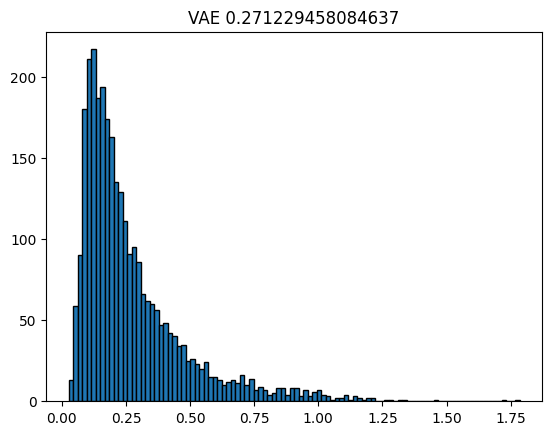

In [53]:
plt.hist(np.array(dist_ratios_vae),bins=100,edgecolor='black')
plt.title(f'VAE {np.mean(dist_ratios_vae)}')
plt.savefig(result_path+'VAE')
plt.show()